In [1]:
suppressPackageStartupMessages({
library(tidyverse)
library(yardstick)
library(cowplot)
library(ggrepel)
library(ggbeeswarm)
})
theme_set(theme_cowplot())
options(repr.plot.width = 15, repr.plot.height = 9)
set.seed(42)

# Performance measure properness
<blockquote>
    A performance measure is called proper if its expected value is optimal when using the correct model, which is the model that gives the correct probabilities based on the predictors or features in the model. Here, expected value refers to the average value obtained after repeating the validation study multiple times. In any given dataset, particularly when sample size is low, the correct model can be outperformed by an incorrect model due to random variation. The importance of properness is that a proper measure cannot be fooled: in expectation, the correct model cannot be outperformed by an incorrect one. A measure is strictly proper when its expected value is optimal only for the correct model. When the expected value is optimal for the correct model and for some incorrect models, a measure is called semi-proper. When an incorrect model can have a better expected value than the correct model, the measure is termed improper and cannot be trusted.
</blockquote>

The above is a quote from the paper ["Evaluation of performance measures in predictive artificial intelligence models to support medical decisions: overview and guidance"](https://doi.org/10.1016/j.landig.2025.100916). In this notebook, I reproduced the results from the Supplementary Appendix 1 of this paper, which demonstrates the properness of some performance metrics.

# Generate data

First we generate some synthetic data, the paper does not provide code for this section but describes:

<blockquote>
    To illustrate the property of properness, we consider a hypothetical situation with four continuous predictors that have a standard normal distribution and that are correlated with each other (Pearson correlation 0.4 between any pair of predictors). The correct model for outcome Y is a logistic model with intercept -1 and predictor coefficients of 0.74, 0.18, 0.18, and 0.18. This setup corresponds to a true AUROC of 0.746 and a prevalence of 0.304. The clinically relevant decision threshold is set to 0.1.
</blockquote>

In [2]:
n_samples = 20000
intercept = -1.0
coefficients = c(0.74, 0.18, 0.18, 0.18)
n_features = length(coefficients)

In [3]:
corr_mat = matrix(0.4, n_features, n_features)
diag(corr_mat) = 1
corr_mat

1.0,0.4,0.4,0.4
0.4,1.0,0.4,0.4
0.4,0.4,1.0,0.4
0.4,0.4,0.4,1.0


In [4]:
L = chol(corr_mat) # Cholesky decomposition
Z = matrix(rnorm(n_samples * n_features), n_samples, n_features)
X = Z %*% L
cor(X)

1.0000000,0.3998118,0.4080561,0.4075815
0.3998118,1.0000000,0.3976041,0.3997537
0.4080561,0.3976041,1.0000000,0.3914141
0.4075815,0.3997537,0.3914141,1.0000000


In [5]:
cor(X) %>%
.[row(.)!=col(.)] |> # exclude diagonal
mean() # paper's target correlation is 0.4

[1] 0.4007036

# Generate models

12 different models are proposed, model 1 is the correct model, and the other eleven are variations that should perform worse.

In [6]:
# 1. true model
trueLP = as.vector(intercept + X %*% coefficients)
probs_1 = plogis(trueLP)
y_true = as.numeric(runif(n_samples) < probs_1)

In [7]:
mean(y_true) # paper's target prevalence is 0.304

[1] 0.30605

In [8]:
# 2. expit(trueLP + 0.75)
probs_2 = plogis(trueLP + 0.75)

In [9]:
# 3. expit(trueLP - 1)
probs_3 = plogis(trueLP - 1)

In [10]:
# 4. expit(trueLP/1.3)
probs_4 = plogis(trueLP / 1.3)

In [11]:
# 5. expit(trueLP*2)
probs_5 = plogis(trueLP * 2)

In [12]:
# 6. expit(trueLP*2 - 1)
probs_6 = plogis(trueLP * 2 - 1)

In [13]:
# 7. prob<0.1 are shrunk by a factor of 10 and prob>=0.1 are blown up with 1 - (0.1 * (1 - prob))
probs_7 = ifelse(probs_1 < 0.1, 0.1 * probs_1, 1 - (0.1 * (1 - probs_1)))

In [14]:
# 8. like 7 but but use prevalence as threshold
probs_8 = ifelse(probs_1 < mean(y_true), 0.1 * probs_1, 1 - (0.1 * (1 - probs_1)))

In [15]:
# 9. like 7 but use 0.5 as threshold
probs_9 = ifelse(probs_1 < 0.5, 0.1 * probs_1, 1 - (0.1 * (1 - probs_1)))

In [16]:
# 10. 0.04 is added or subtracted at random to prob range [0.051, 0.949]
probs_10 = ifelse(probs_1 >= 0.051 & probs_1 <= 0.949, probs_1+ifelse(rbinom(n_samples, 1, 0.5), 0.04, -0.04), probs_1)

In [17]:
# 11. expit(trueLP + U(-0.2,0.2)), a random value in the range [-0.2, 0.2]
probs_11 = plogis(trueLP + runif(n_samples, min=-0.2, max=0.2))

In [18]:
# 12. use coefficients 0.74, 0.74, 0.18, and 0.18
modLP = as.vector(intercept + X %*% c(0.74, 0.74, 0.18, 0.18))
probs_12 = plogis(modLP)

In [19]:
df <- tibble(
    y_true,
    probs_1, probs_2, probs_3, probs_4,
    probs_5, probs_6, probs_7, probs_8,
    probs_9, probs_10, probs_11, probs_12
) |>
pivot_longer(names_to = 'model', values_to = 'prob', contains('probs')) |>
mutate(
    gt=factor(ifelse(y_true, '1','0'), levels=c('1','0')),
    model=gsub('probs_', '',model),
    model=factor(model, levels=sort(as.numeric(unique(model)))),
)

In [20]:
filter(df, model==1) |>
roc_auc(gt, prob) # paper's target roc_auc is 0.746

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
roc_auc,binary,0.7462845


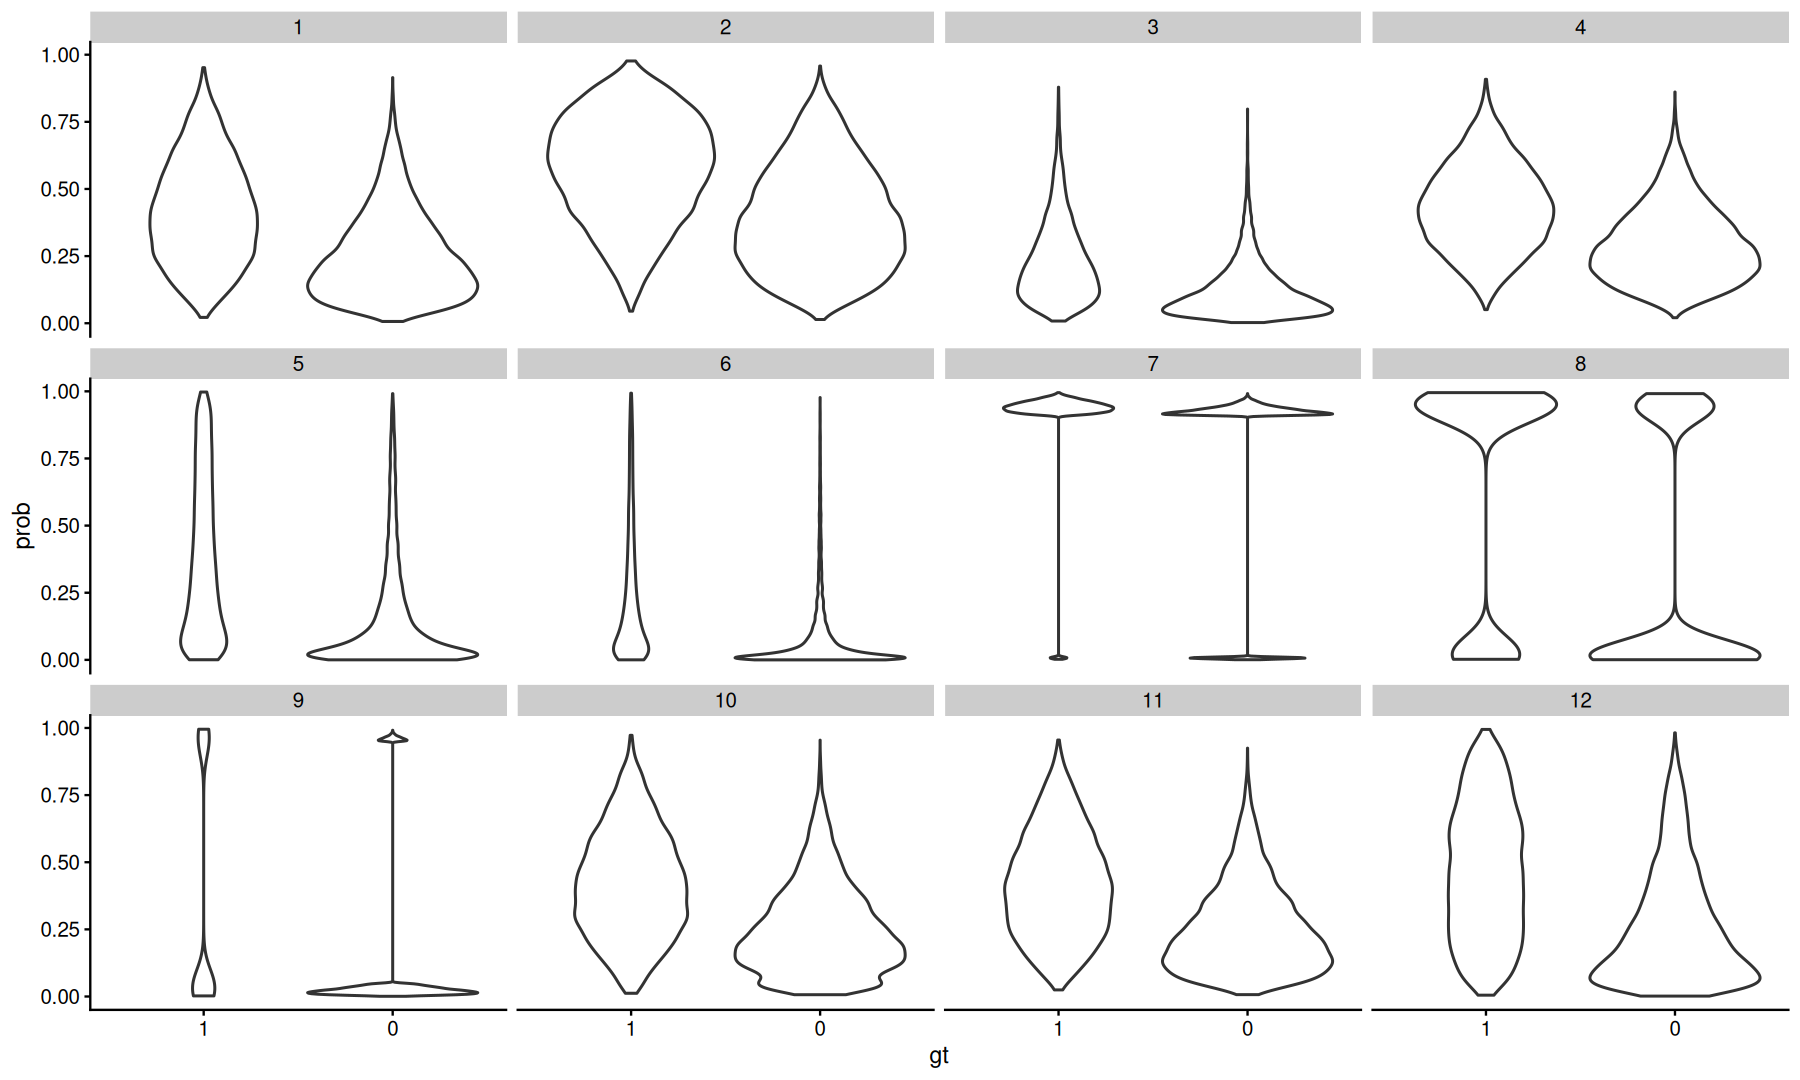

In [21]:
df |>
ggplot(aes(x=gt, y=prob)) +
geom_violin() + 
facet_wrap(~model)

# Evaluation 

To calculate the performance metrics, I will use the [yardstick](https://yardstick.tidymodels.org/index.html) package. See their doc for the definition of each metric used here.

## Class Probability Metrics

Class probability metrics are measures that evaluate model performance based on the predicted probability assigned to the target classes. 

These metrics do not depend on a definition of a prediction threshold.

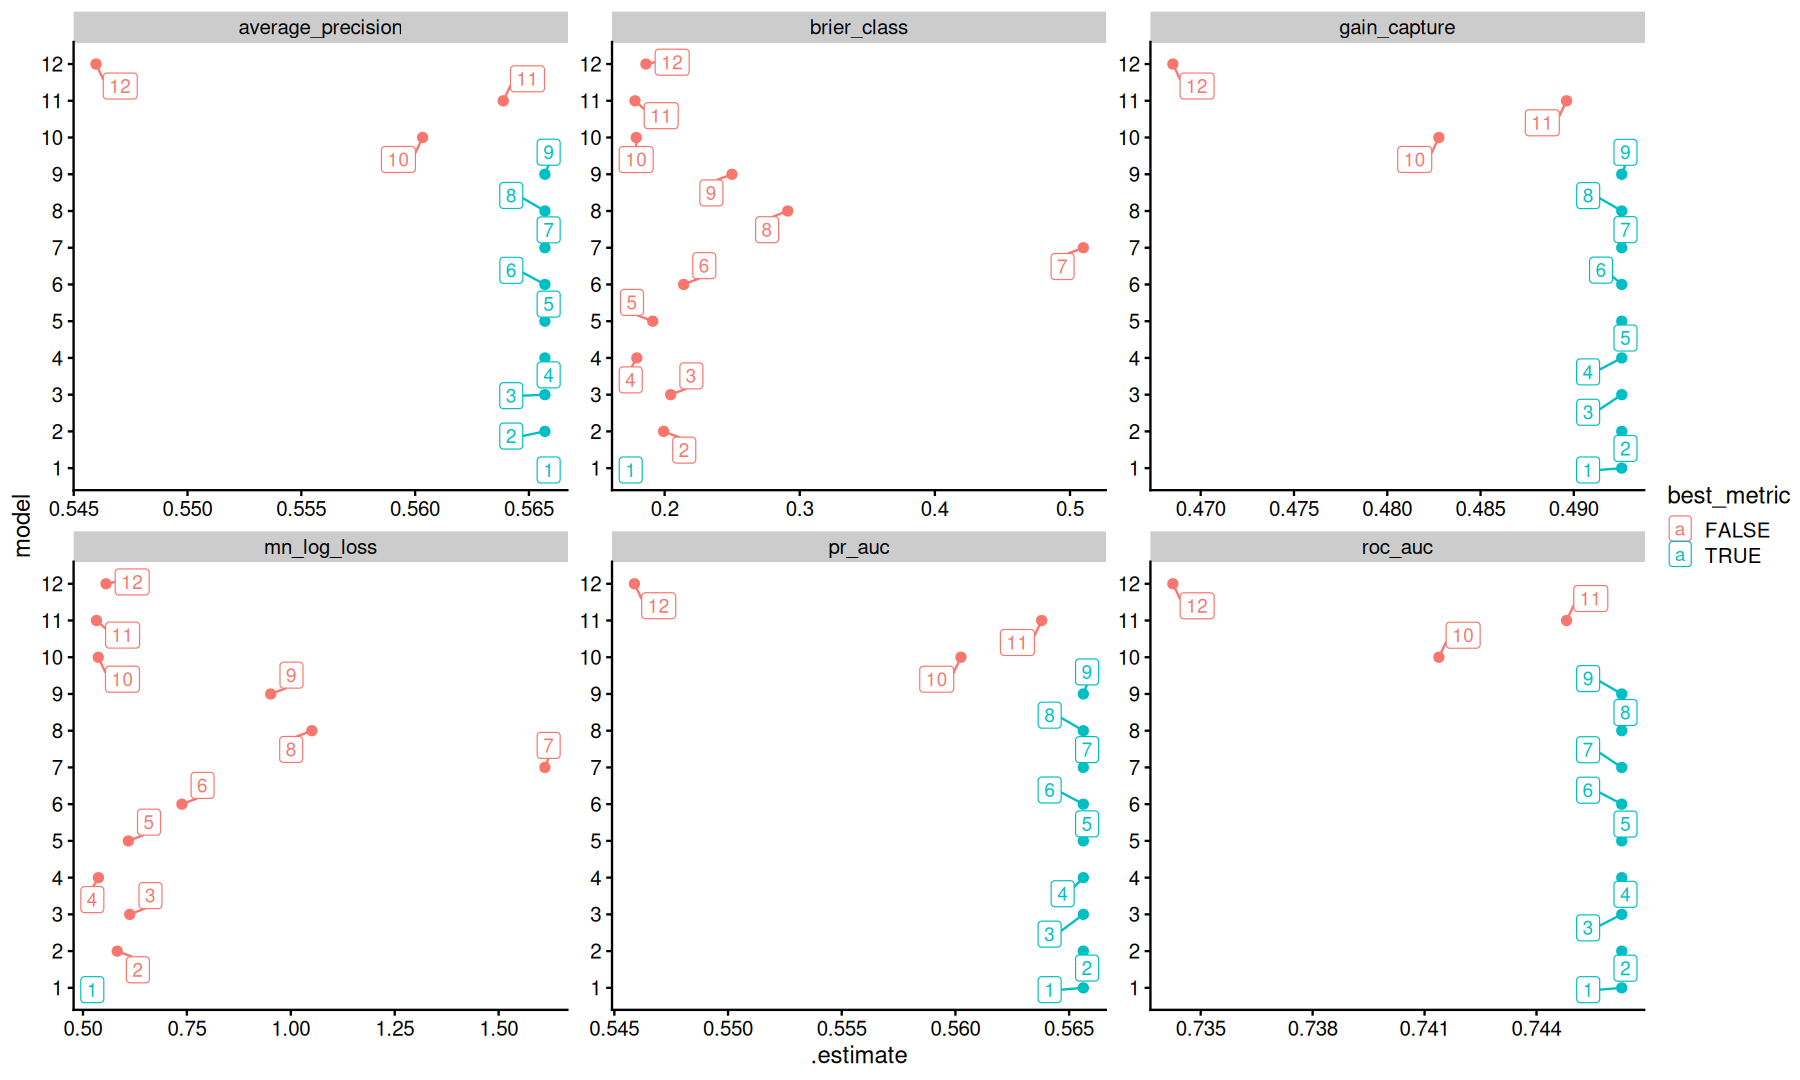

In [22]:
ms = metric_set(roc_auc, pr_auc, mn_log_loss, average_precision, brier_class, gain_capture)
df |>
group_by(model) |>
ms(gt, prob) |>
mutate(
    best_metric = ifelse(.metric %in% c('brier_class','mn_log_loss'), .estimate == min(.estimate), .estimate == max(.estimate)),
    .by = .metric
) |>
ggplot(aes(y=model, x=.estimate, color=best_metric)) +
geom_point() +
geom_label_repel(aes(label=model), max.overlaps = Inf, min.segment.length = 0, box.padding = 0.3) +
facet_wrap(~.metric, scales='free')

`mn_log_loss` and `brier_class` are strictly proper metrics, therefore, only the correct model has the best metric.

The other metrics are semi-proper, because we can't distinguish between the correct model and the others.

## Classification Metrics

Classification metrics are measures that evaluate model performance based on the predicted class labels.

These metrics require a prediction threshold to transform a predicted probabilities into discrete class predictions. For this experiment, the threshold was set at 0.1.

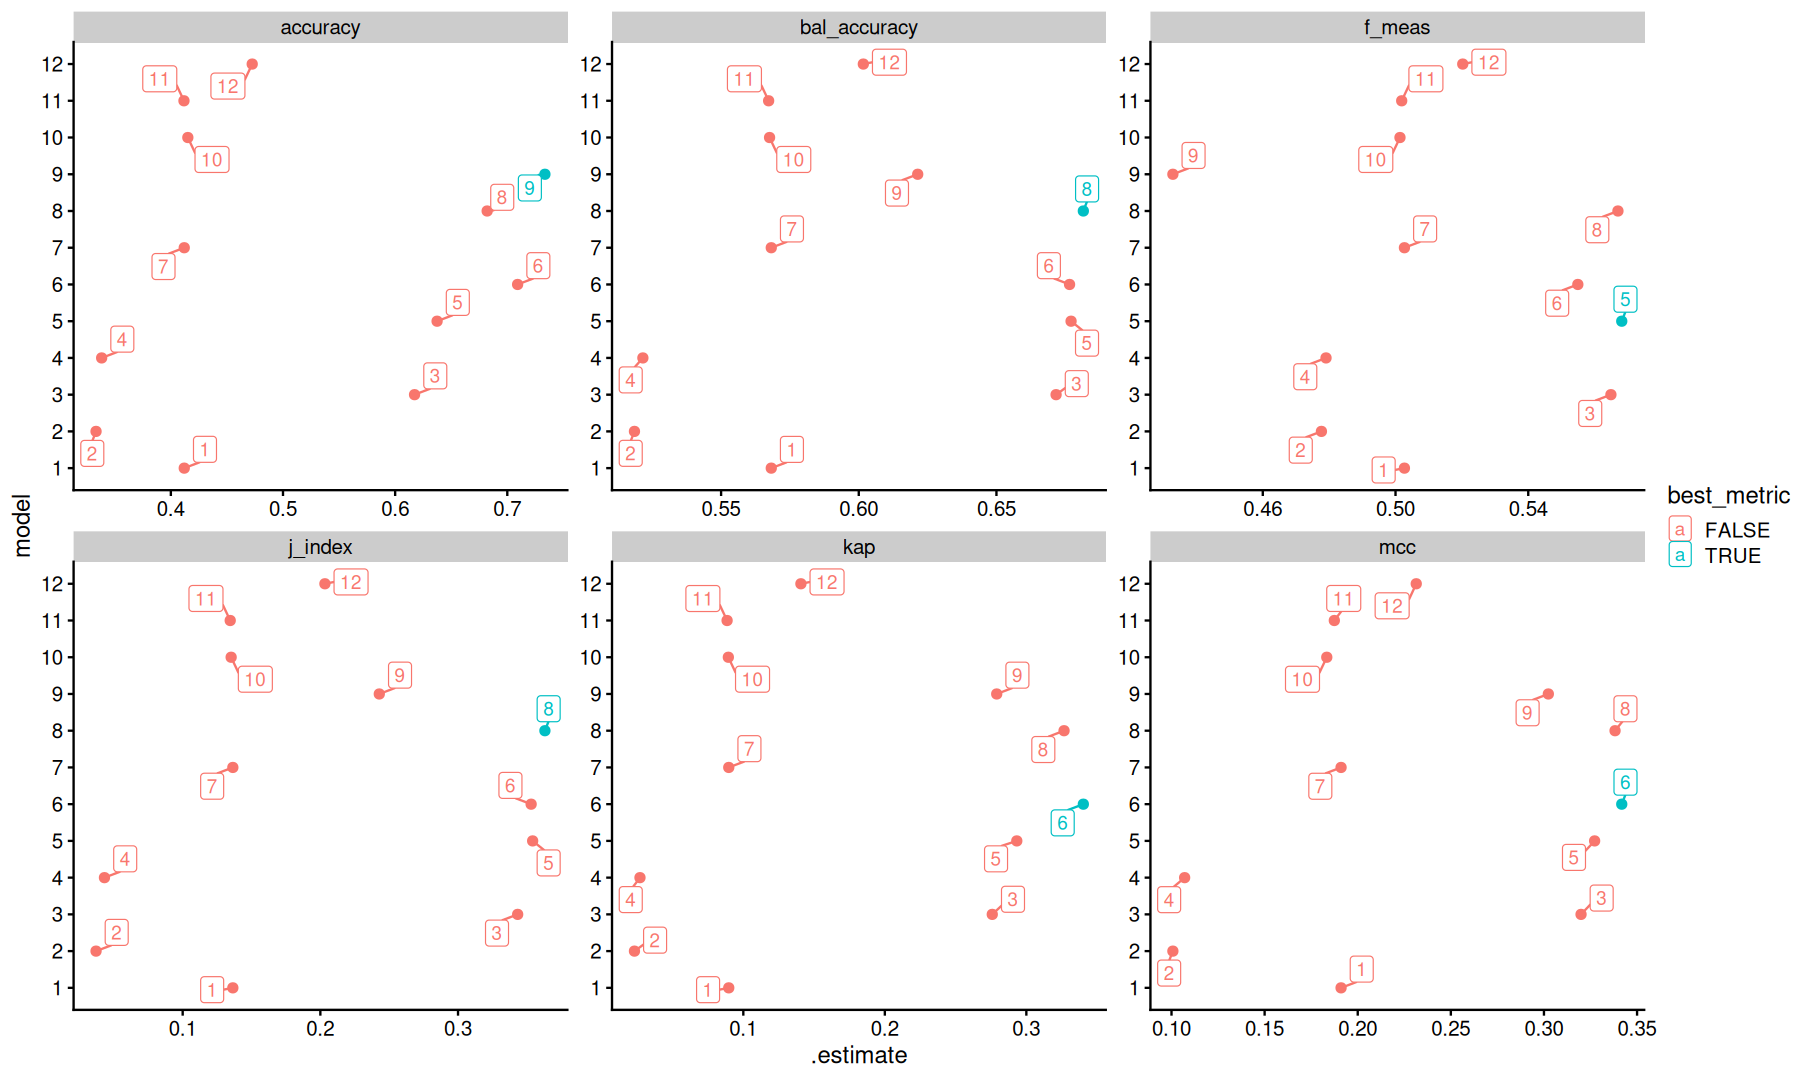

In [23]:
ms = metric_set(mcc, kap, j_index, f_meas, accuracy, bal_accuracy)
df |>
mutate(
    est=factor(ifelse(prob>0.1, '1','0'), levels=c('1','0'))
) |>
group_by(model) |>
ms(gt, estimate=est) |>
mutate(
    best_metric = .estimate == max(.estimate),
    .by = .metric
) |>
ggplot(aes(y=model, x=.estimate, color=best_metric)) +
geom_point() +
geom_label_repel(aes(label=model), max.overlaps = Inf, min.segment.length = 0, box.padding = 0.3) +
facet_wrap(~.metric, scales='free')

All metrics tested were improper, because the correct model had a worse metric than some of the other models.

## Regression metrics

Regression probability metrics are measures that evaluate model performance based on the predicted continuous output values rather than discrete categories.

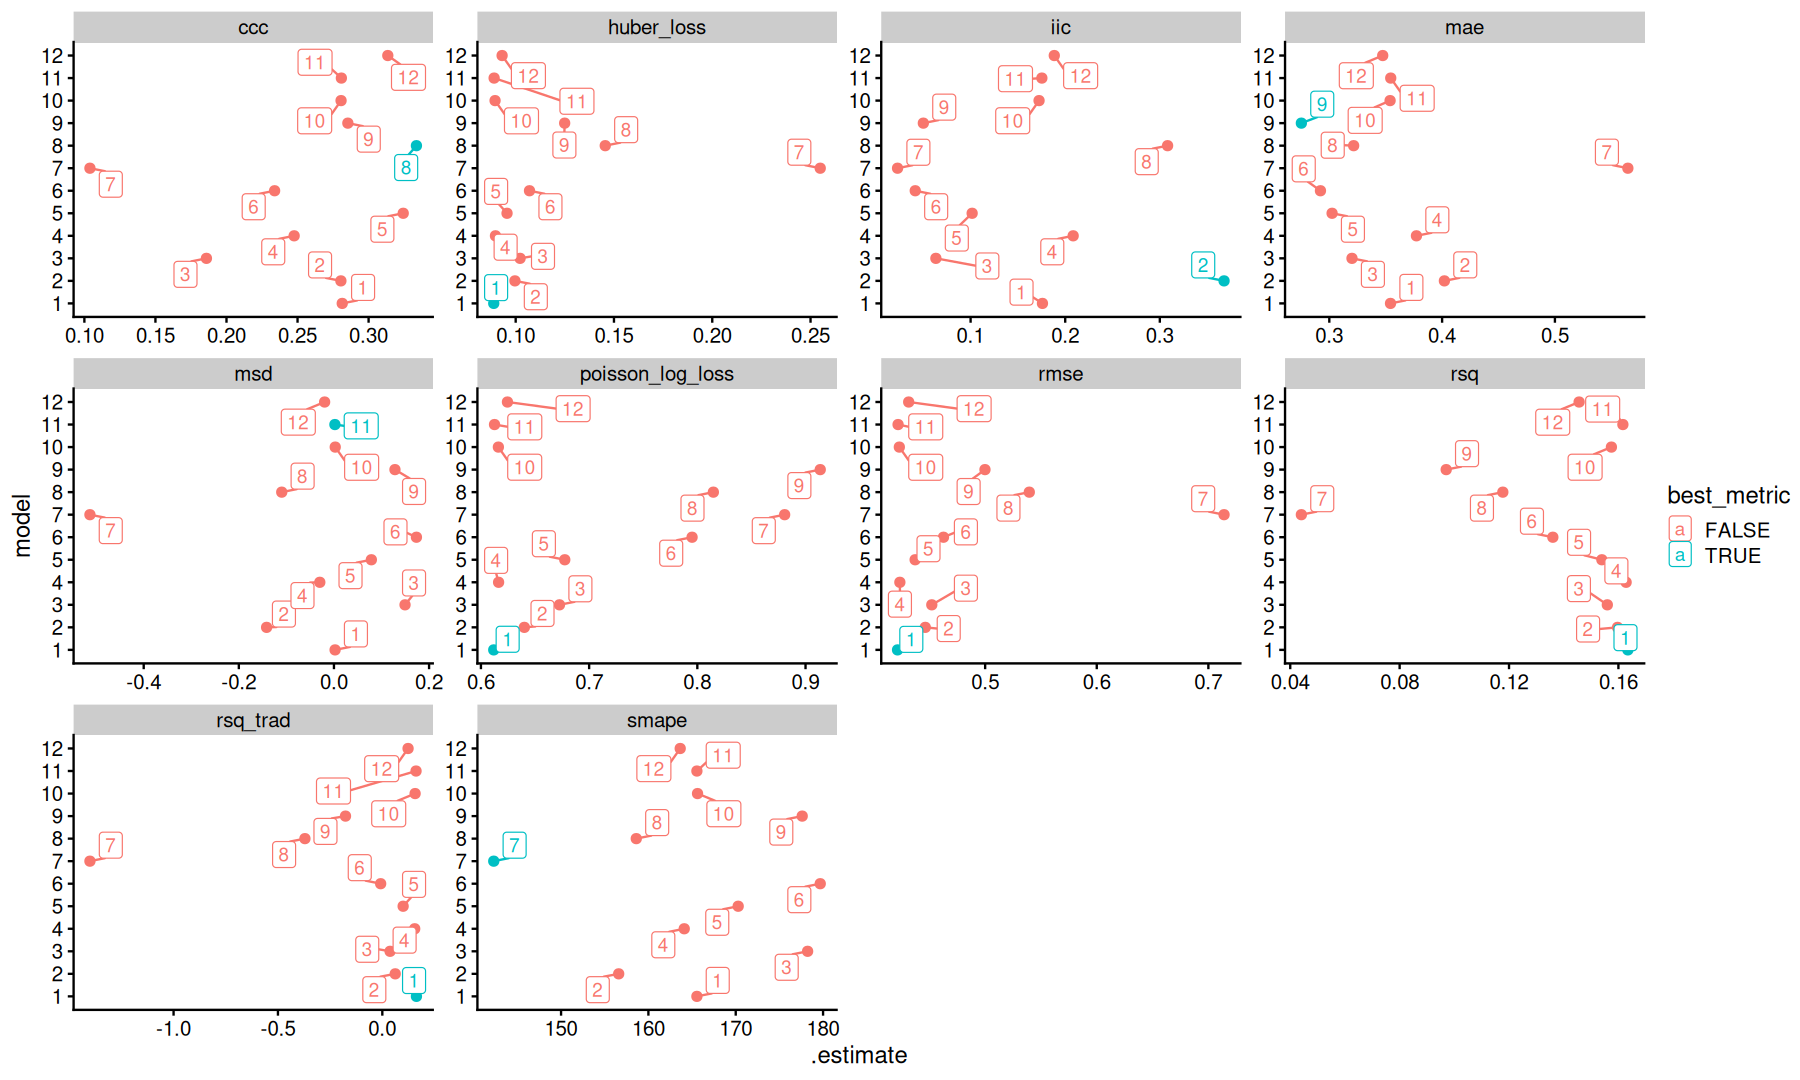

In [24]:
ms = metric_set(rmse, rsq, rsq_trad, mae, ccc, huber_loss, iic, poisson_log_loss, smape, msd, )
df |>
group_by(model) |>
ms(y_true, prob) |>
mutate(
    best_metric = case_when(
        .metric == 'msd' ~ abs(.estimate) == min(abs(.estimate)),
        .metric %in% c('ccc','iic','rsq','rsq_trad') ~ .estimate == max(.estimate),
        TRUE ~ .estimate == min(.estimate)
    ),
    .by = .metric
) |>
ggplot(aes(y=model, x=.estimate, color=best_metric)) +
geom_point() +
geom_label_repel(aes(label=model),max.overlaps = Inf, min.segment.length = 0, box.padding = 0.3) +
facet_wrap(~.metric, scales='free')

`rmse`, `huber_loss`, `rsq`, `rsq_trad` and `poisson_log_loss` are strictly proper.

The others are improper.